In [1]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

#try:
#    from implicit.gpu.als import AlternatingLeastSquares
#    print("implicit: используется GPU")
#except Exception:
#    from implicit.als import AlternatingLeastSquares
#    print("implicit: GPU недоступен, используется CPU")

from implicit.als import AlternatingLeastSquares

from implicit.nearest_neighbours import bm25_weight

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

SEED = 42
DATA_PATH = '../data/children_products/clildren_product_cleaned.csv'
MIN_INTERACTIONS = 3
SPLIT_QUANTILE = 0.7
K_VALUES = [5, 10, 20]


In [ ]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df = df.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')
df = df.dropna(subset=['Дата'])

if 'Цена' in df.columns:
    df['Цена'] = df['Цена'].astype(str).str.replace(' ', '').str.replace(',', '.')
    df['Цена'] = pd.to_numeric(df['Цена'], errors='coerce')

uc = df.groupby('Телефон_new').size()
ic = df.groupby('ID_SKU').size()
df = df[
    df['Телефон_new'].isin(uc[uc >= MIN_INTERACTIONS].index) &
    df['ID_SKU'].isin(ic[ic >= MIN_INTERACTIONS].index)
]
print(f'After filter: users={df["Телефон_new"].nunique():,}, '
      f'items={df["ID_SKU"].nunique():,}, rows={len(df):,}')


After filter: users=35,395, items=22,198, rows=314,493


In [4]:
interactions = (
    df.groupby(['Телефон_new', 'ID_SKU'])
      .agg(last_date=('Дата', 'max'),
           mean_date=('Дата', 'mean'),
           count=('Дата', 'count'))
      .reset_index()
)

user_enc = LabelEncoder()
item_enc = LabelEncoder()
interactions['user_id'] = user_enc.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_enc.fit_transform(interactions['ID_SKU'])

N_USERS = interactions['user_id'].nunique()
N_ITEMS = interactions['item_id'].nunique()
print(f'Unique pairs: {len(interactions):,}, N_USERS={N_USERS:,}, N_ITEMS={N_ITEMS:,}')


Unique pairs: 287,360, N_USERS=35,395, N_ITEMS=22,198


In [6]:
split_ts = interactions['last_date'].quantile(SPLIT_QUANTILE)
print(f'Split timestamp: {split_ts}')

train_df = interactions[interactions['last_date'] <  split_ts].copy()
test_df  = interactions[interactions['last_date'] >= split_ts].copy()

train_users = set(train_df['user_id'].unique())
test_warm = test_df[ test_df['user_id'].isin(train_users)].copy()
test_cold = test_df[~test_df['user_id'].isin(train_users)].copy()

print(f'Train:     {len(train_df):,} pairs / {train_df["user_id"].nunique():,} users')
print(f'Test warm: {len(test_warm):,} pairs / {test_warm["user_id"].nunique():,} users')
print(f'Test cold: {len(test_cold):,} pairs / {test_cold["user_id"].nunique():,} users')

# Sanity: no leakage between train and test (same (user, item) pairs cannot appear in both)
_leak = train_df.merge(test_df, on=['user_id', 'item_id'])
assert len(_leak) == 0, f'Leakage: {len(_leak)} pairs in both train and test'


Split timestamp: 2017-04-12 17:37:00
Train:     201,147 pairs / 28,017 users
Test warm: 42,415 pairs / 7,128 users
Test cold: 43,798 pairs / 7,378 users


In [7]:

n_users = N_USERS
n_items = N_ITEMS

train_interactions      = train_df[['user_id', 'item_id', 'count']].copy()
test_interactions       = test_warm[['user_id', 'item_id', 'count']].copy()
test_interactions_cold  = test_cold[['user_id', 'item_id', 'count']].copy()

train_data = train_df[['user_id', 'item_id', 'count', 'mean_date']].copy()
train_data = train_data.rename(columns={'mean_date': 'Дата'})

split_date = split_ts

print(f'n_users={n_users:,}, n_items={n_items:,}')
print(f'Train pairs: {len(train_interactions):,}')
print(f'Test warm:   {len(test_interactions):,}  ({test_interactions["user_id"].nunique():,} users)')
print(f'Test cold:   {len(test_interactions_cold):,}  ({test_interactions_cold["user_id"].nunique():,} users)')


n_users=35,395, n_items=22,198
Train pairs: 201,147
Test warm:   42,415  (7,128 users)
Test cold:   43,798  (7,378 users)


In [8]:
def create_sparse_matrix(interactions_df, n_users, n_items):
    return csr_matrix(
        (interactions_df['count'].values,
         (interactions_df['user_id'].values, interactions_df['item_id'].values)),
        shape=(n_users, n_items)
    )

def get_recommendations(model, user_id, train_matrix, k=10, filter_already_liked=True):
    item_ids, scores = model.recommend(
        user_id,
        train_matrix[user_id],
        N=k,
        filter_already_liked_items=filter_already_liked
    )
    return list(item_ids), list(scores)

def precision_at_k(recommended_items, relevant_items, k):
    recommended_k = set(recommended_items[:k])
    relevant = set(relevant_items)
    if len(recommended_k) == 0:
        return 0.0
    return len(recommended_k & relevant) / len(recommended_k)

def recall_at_k(recommended_items, relevant_items, k):
    recommended_k = set(recommended_items[:k])
    relevant = set(relevant_items)
    if len(relevant) == 0:
        return 0.0
    return len(recommended_k & relevant) / len(relevant)

def map_at_k(recommended_items, relevant_items, k):
    relevant = set(relevant_items)
    if len(relevant) == 0:
        return 0.0
    score = 0.0
    num_hits = 0.0
    for i, item in enumerate(recommended_items[:k]):
        if item in relevant:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    return score / min(len(relevant), k)

def ndcg_at_k(recommended_items, relevant_items, k):
    relevant = set(relevant_items)
    if len(relevant) == 0:
        return 0.0
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended_items[:k]) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_model(model, train_matrix, test_interactions, k_values=[5, 10, 20], eval_users=None):
    test_user_items = test_interactions.groupby('user_id')['item_id'].apply(list).to_dict()
    if eval_users is None:
        train_users_set = set(np.where(train_matrix.getnnz(axis=1) > 0)[0])
        eval_users = [u for u in test_user_items if u in train_users_set]

    results = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}
    for user_id in eval_users:
        try:
            rec_items, _ = get_recommendations(model, user_id, train_matrix, k=max(k_values))
            relevant = test_user_items[user_id]
            for k in k_values:
                results[k]['precision'].append(precision_at_k(rec_items, relevant, k))
                results[k]['recall'].append(recall_at_k(rec_items, relevant, k))
                results[k]['map'].append(map_at_k(rec_items, relevant, k))
                results[k]['ndcg'].append(ndcg_at_k(rec_items, relevant, k))
        except Exception:
            for k in k_values:
                results[k]['precision'].append(0.0)
                results[k]['recall'].append(0.0)
                results[k]['map'].append(0.0)
                results[k]['ndcg'].append(0.0)
            continue

    return {k: {m: np.mean(v) for m, v in results[k].items()} for k in k_values}

def eval_warm_cold(model, train_matrix, k_values=[5, 10, 20]):
    warm_users = test_interactions['user_id'].unique().tolist()
    cold_users = test_interactions_cold['user_id'].unique().tolist()
    warm = evaluate_model(model, train_matrix, test_interactions,
                          k_values=k_values, eval_users=warm_users)
    if len(cold_users) > 0:
        cold = evaluate_model(model, train_matrix, test_interactions_cold,
                              k_values=k_values, eval_users=cold_users)
    else:
        cold = {k: {'precision': 0.0, 'recall': 0.0, 'map': 0.0, 'ndcg': 0.0} for k in k_values}
    return warm, cold


def _print_metrics(name, warm, cold, k_values=[5, 10, 20]):
    print(f'=== {name} ===')
    for cohort, res in [('warm', warm), ('cold', cold)]:
        for k in k_values:
            r = res[k]
            print(f'  [{cohort}] K={k:>2}: P={r["precision"]:.4f}  R={r["recall"]:.4f}  '
                  f'MAP={r["map"]:.4f}  NDCG={r["ndcg"]:.4f}')


In [9]:
train_matrix_standard = create_sparse_matrix(train_interactions, n_users, n_items)
print(f"Train матрица (стандарт): {train_matrix_standard.shape}, ненулевых: {train_matrix_standard.nnz:,}")

Train матрица (стандарт): (35395, 22198), ненулевых: 201,147


In [10]:
model_standard_baseline = AlternatingLeastSquares(
    factors=50, regularization=0.01, iterations=15,
    calculate_training_loss=False, random_state=42
)
model_standard_baseline.fit(train_matrix_standard)

results_standard_baseline_warm, results_standard_baseline_cold = eval_warm_cold(
    model_standard_baseline, train_matrix_standard
)
results_standard_baseline = results_standard_baseline_warm

print("=== Стандарт + дефолт ===")
for k in [5, 10, 20]:
    r = results_standard_baseline[k]
    print(f"  K={k}: P={r['precision']:.4f}  R={r['recall']:.4f}  MAP={r['map']:.4f}  NDCG={r['ndcg']:.4f}")

/opt/homebrew/Caskroom/miniconda/base/envs/data_analysis/lib/python3.11/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

=== Стандарт + дефолт ===
  K=5: P=0.0442  R=0.0474  MAP=0.0432  NDCG=0.0624
  K=10: P=0.0348  R=0.0661  MAP=0.0396  NDCG=0.0646
  K=20: P=0.0262  R=0.0900  MAP=0.0395  NDCG=0.0709


In [11]:
DECAY_LAMBDA = 0.01  
train_with_time = train_data.groupby(['user_id', 'item_id']).agg(
    count=('count', 'sum'),
    mean_date=('Дата', 'mean')
).reset_index()

days_before_split = (split_date - train_with_time['mean_date']).dt.total_seconds() / 86400
train_with_time['count'] = train_with_time['count'] * np.exp(-DECAY_LAMBDA * days_before_split)
train_with_time['count'] = train_with_time['count'].clip(lower=1e-6)

train_matrix_decay = create_sparse_matrix(train_with_time, n_users, n_items)
print(f"Train матрица (затухание): {train_matrix_decay.shape}, ненулевых: {train_matrix_decay.nnz:,}")
print(f"Диапазон весов: [{train_with_time['count'].min():.4f}, {train_with_time['count'].max():.4f}]")

Train матрица (затухание): (35395, 22198), ненулевых: 201,147
Диапазон весов: [0.6523, 22.3579]


In [12]:
model_decay_baseline = AlternatingLeastSquares(
    factors=50, regularization=0.01, iterations=15,
    calculate_training_loss=False, random_state=42
)
model_decay_baseline.fit(train_matrix_decay)

results_decay_baseline_warm, results_decay_baseline_cold = eval_warm_cold(
    model_decay_baseline, train_matrix_decay
)
results_decay_baseline = results_decay_baseline_warm

for k in [5, 10, 20]:
    r = results_decay_baseline[k]
    print(f"  K={k}: P={r['precision']:.4f}  R={r['recall']:.4f}  MAP={r['map']:.4f}  NDCG={r['ndcg']:.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]

  K=5: P=0.0424  R=0.0421  MAP=0.0392  NDCG=0.0572
  K=10: P=0.0331  R=0.0609  MAP=0.0354  NDCG=0.0591
  K=20: P=0.0249  R=0.0822  MAP=0.0351  NDCG=0.0645


In [13]:
train_matrix_bm25 = bm25_weight(train_matrix_standard.T, K1=100, B=0.8).T.tocsr()

print(f"Train матрица (BM25): {train_matrix_bm25.shape}, ненулевых: {train_matrix_bm25.nnz:,}")
bm25_vals = train_matrix_bm25.data
print(f"Диапазон весов: [{bm25_vals.min():.4f}, {bm25_vals.max():.4f}]")
print(f"Среднее значение: {bm25_vals.mean():.4f}  (стандарт: {train_matrix_standard.data.mean():.4f})")

Train матрица (BM25): (35395, 22198), ненулевых: 201,147
Диапазон весов: [0.0676, 65.7950]
Среднее значение: 5.7258  (стандарт: 1.0639)


In [14]:
model_bm25_baseline = AlternatingLeastSquares(
    factors=50, regularization=0.01, iterations=15,
    calculate_training_loss=False, random_state=42
)
model_bm25_baseline.fit(train_matrix_bm25)

results_bm25_baseline_warm, results_bm25_baseline_cold = eval_warm_cold(
    model_bm25_baseline, train_matrix_bm25
)
results_bm25_baseline = results_bm25_baseline_warm

print("=== BM25 + дефолт ===")
for k in [5, 10, 20]:
    r = results_bm25_baseline[k]
    print(f"  K={k}: P={r['precision']:.4f}  R={r['recall']:.4f}  MAP={r['map']:.4f}  NDCG={r['ndcg']:.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]

=== BM25 + дефолт ===
  K=5: P=0.0044  R=0.0035  MAP=0.0036  NDCG=0.0055
  K=10: P=0.0039  R=0.0063  MAP=0.0033  NDCG=0.0060
  K=20: P=0.0030  R=0.0091  MAP=0.0032  NDCG=0.0066


In [15]:
SEARCH_K      = 10
SEARCH_METRIC = 'ndcg'  # метрика оптимизации Optuna
N_TRIALS      = 30

def make_objective(train_matrix):
    def objective(trial):
        factors        = trial.suggest_int('factors', 10, 100)
        regularization = trial.suggest_float('regularization', 1e-4, 10.0, log=True)
        iterations     = trial.suggest_int('iterations', 5, 50)
        m = AlternatingLeastSquares(
            factors=factors, regularization=regularization,
            iterations=iterations, random_state=42, calculate_training_loss=False
        )
        m.fit(train_matrix, show_progress=False)
        r = evaluate_model(m, train_matrix, test_interactions, k_values=[SEARCH_K])
        return r[SEARCH_K][SEARCH_METRIC]
    return objective


In [16]:
study_standard = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='ALS_TPE_standard'
)
study_standard.optimize(
    make_objective(train_matrix_standard),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print(f"\nСтандарт — лучший {SEARCH_METRIC.upper()}@{SEARCH_K}: {study_standard.best_value:.4f}")
print(f"Параметры: {study_standard.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


Стандарт — лучший NDCG@10: 0.0750
Параметры: {'factors': 34, 'regularization': 9.114752132084432, 'iterations': 23}


In [17]:
bp_std = study_standard.best_params
model_standard_optuna = AlternatingLeastSquares(
    factors=bp_std['factors'], regularization=bp_std['regularization'],
    iterations=bp_std['iterations'], random_state=42, calculate_training_loss=False
)
model_standard_optuna.fit(train_matrix_standard, show_progress=False)
results_standard_optuna_warm, results_standard_optuna_cold = eval_warm_cold(
    model_standard_optuna, train_matrix_standard
)
results_standard_optuna = results_standard_optuna_warm
print("=== Стандарт + Optuna TPE ===")
for k in [5, 10, 20]:
    r = results_standard_optuna[k]
    print(f"  K={k}: P={r['precision']:.4f}  R={r['recall']:.4f}  MAP={r['map']:.4f}  NDCG={r['ndcg']:.4f}")

=== Стандарт + Optuna TPE ===
  K=5: P=0.0512  R=0.0597  MAP=0.0507  NDCG=0.0726
  K=10: P=0.0392  R=0.0803  MAP=0.0468  NDCG=0.0750
  K=20: P=0.0292  R=0.1060  MAP=0.0468  NDCG=0.0819


In [18]:
study_decay = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='ALS_TPE_decay'
)
study_decay.optimize(
    make_objective(train_matrix_decay),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print(f"\nЗатухание — лучший {SEARCH_METRIC.upper()}@{SEARCH_K}: {study_decay.best_value:.4f}")
print(f"Параметры: {study_decay.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


Затухание — лучший NDCG@10: 0.0777
Параметры: {'factors': 98, 'regularization': 9.523948773100468, 'iterations': 40}


In [19]:
bp_dec = study_decay.best_params
model_decay_optuna = AlternatingLeastSquares(
    factors=bp_dec['factors'], regularization=bp_dec['regularization'],
    iterations=bp_dec['iterations'], random_state=42, calculate_training_loss=False
)
model_decay_optuna.fit(train_matrix_decay, show_progress=False)
results_decay_optuna_warm, results_decay_optuna_cold = eval_warm_cold(
    model_decay_optuna, train_matrix_decay
)
results_decay_optuna = results_decay_optuna_warm
print('=== Затухание + Optuna TPE ===')
for k in [5, 10, 20]:
    r = results_decay_optuna[k]
    print(f'  K={k}: P={r["precision"]:.4f}  R={r["recall"]:.4f}  MAP={r["map"]:.4f}  NDCG={r["ndcg"]:.4f}')


=== Затухание + Optuna TPE ===
  K=5: P=0.0519  R=0.0626  MAP=0.0511  NDCG=0.0738
  K=10: P=0.0408  R=0.0861  MAP=0.0481  NDCG=0.0777
  K=20: P=0.0307  R=0.1132  MAP=0.0485  NDCG=0.0852


In [20]:
study_bm25 = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='ALS_TPE_bm25'
)
study_bm25.optimize(
    make_objective(train_matrix_bm25),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print(f"\nBM25 — лучший {SEARCH_METRIC.upper()}@{SEARCH_K}: {study_bm25.best_value:.4f}")
print(f"Параметры: {study_bm25.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


BM25 — лучший NDCG@10: 0.0091
Параметры: {'factors': 100, 'regularization': 0.013033183219937985, 'iterations': 26}


In [21]:
bp_bm25 = study_bm25.best_params
model_bm25_optuna = AlternatingLeastSquares(
    factors=bp_bm25['factors'], regularization=bp_bm25['regularization'],
    iterations=bp_bm25['iterations'], random_state=42, calculate_training_loss=False
)
model_bm25_optuna.fit(train_matrix_bm25, show_progress=False)
results_bm25_optuna_warm, results_bm25_optuna_cold = eval_warm_cold(
    model_bm25_optuna, train_matrix_bm25
)
results_bm25_optuna = results_bm25_optuna_warm
print("=== BM25 + Optuna TPE ===")
for k in [5, 10, 20]:
    r = results_bm25_optuna[k]
    print(f"  K={k}: P={r['precision']:.4f}  R={r['recall']:.4f}  MAP={r['map']:.4f}  NDCG={r['ndcg']:.4f}")

=== BM25 + Optuna TPE ===
  K=5: P=0.0064  R=0.0060  MAP=0.0057  NDCG=0.0086
  K=10: P=0.0055  R=0.0091  MAP=0.0052  NDCG=0.0091
  K=20: P=0.0045  R=0.0137  MAP=0.0052  NDCG=0.0103


In [22]:
all_variants = [
    ('Стандарт + дефолт',      results_standard_baseline),
    ('Затухание + дефолт',     results_decay_baseline),
    ('BM25 + дефолт',          results_bm25_baseline),
    ('Стандарт + Optuna TPE',  results_standard_optuna),
    ('Затухание + Optuna TPE', results_decay_optuna),
    ('BM25 + Optuna TPE',      results_bm25_optuna),
]

rows = []
for label, results in all_variants:
    for k in [5, 10, 20]:
        r = results[k]
        rows.append({
            'Вариант': label,
            'K': k,
            'Precision': round(r['precision'], 4),
            'Recall':    round(r['recall'],    4),
            'MAP':       round(r['map'],       4),
            'NDCG':      round(r['ndcg'],      4),
        })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

# === Warm vs Cold table ===
warm_results_map = {
    'Стандарт + дефолт':      results_standard_baseline_warm,
    'Затухание + дефолт':     results_decay_baseline_warm,
    'BM25 + дефолт':          results_bm25_baseline_warm,
    'Стандарт + Optuna TPE':  results_standard_optuna_warm,
    'Затухание + Optuna TPE': results_decay_optuna_warm,
    'BM25 + Optuna TPE':      results_bm25_optuna_warm,
}
cold_results_map = {
    'Стандарт + дефолт':      results_standard_baseline_cold,
    'Затухание + дефолт':     results_decay_baseline_cold,
    'BM25 + дефолт':          results_bm25_baseline_cold,
    'Стандарт + Optuna TPE':  results_standard_optuna_cold,
    'Затухание + Optuna TPE': results_decay_optuna_cold,
    'BM25 + Optuna TPE':      results_bm25_optuna_cold,
}

cohort_rows = []
for cohort, table in [('warm', warm_results_map), ('cold', cold_results_map)]:
    for label, results in table.items():
        for k in [5, 10, 20]:
            r = results[k]
            cohort_rows.append({
                'Вариант': label,
                'Cohort':  cohort,
                'K': k,
                'Precision': round(r['precision'], 4),
                'Recall':    round(r['recall'],    4),
                'MAP':       round(r['map'],       4),
                'NDCG':      round(r['ndcg'],      4),
            })
cohort_df = pd.DataFrame(cohort_rows)
print('\n=== Метрики по когортам (warm / cold) ===')
print(cohort_df.to_string(index=False))


               Вариант  K  Precision  Recall    MAP   NDCG
     Стандарт + дефолт  5     0.0442  0.0474 0.0432 0.0624
     Стандарт + дефолт 10     0.0348  0.0661 0.0396 0.0646
     Стандарт + дефолт 20     0.0262  0.0900 0.0395 0.0709
    Затухание + дефолт  5     0.0424  0.0421 0.0392 0.0572
    Затухание + дефолт 10     0.0331  0.0609 0.0354 0.0591
    Затухание + дефолт 20     0.0249  0.0822 0.0351 0.0645
         BM25 + дефолт  5     0.0044  0.0035 0.0036 0.0055
         BM25 + дефолт 10     0.0039  0.0063 0.0033 0.0060
         BM25 + дефолт 20     0.0030  0.0091 0.0032 0.0066
 Стандарт + Optuna TPE  5     0.0512  0.0597 0.0507 0.0726
 Стандарт + Optuna TPE 10     0.0392  0.0803 0.0468 0.0750
 Стандарт + Optuna TPE 20     0.0292  0.1060 0.0468 0.0819
Затухание + Optuna TPE  5     0.0519  0.0626 0.0511 0.0738
Затухание + Optuna TPE 10     0.0408  0.0861 0.0481 0.0777
Затухание + Optuna TPE 20     0.0307  0.1132 0.0485 0.0852
     BM25 + Optuna TPE  5     0.0064  0.0060 0.0057 0.00

In [23]:
print(f"=== Лучшие гиперпараметры (Optuna TPE, оптимизация: {SEARCH_METRIC.upper()}@{SEARCH_K}) ===")
for name, study in [('Стандарт', study_standard), ('Затухание', study_decay), ('BM25', study_bm25)]:
    print(f"\n{name} ({SEARCH_METRIC.upper()}@{SEARCH_K}={study.best_value:.4f}):")
    for p, v in study.best_params.items():
        print(f"  {p} = {v}")

=== Лучшие гиперпараметры (Optuna TPE, оптимизация: NDCG@10) ===

Стандарт (NDCG@10=0.0750):
  factors = 34
  regularization = 9.114752132084432
  iterations = 23

Затухание (NDCG@10=0.0777):
  factors = 98
  regularization = 9.523948773100468
  iterations = 40

BM25 (NDCG@10=0.0091):
  factors = 100
  regularization = 0.013033183219937985
  iterations = 26


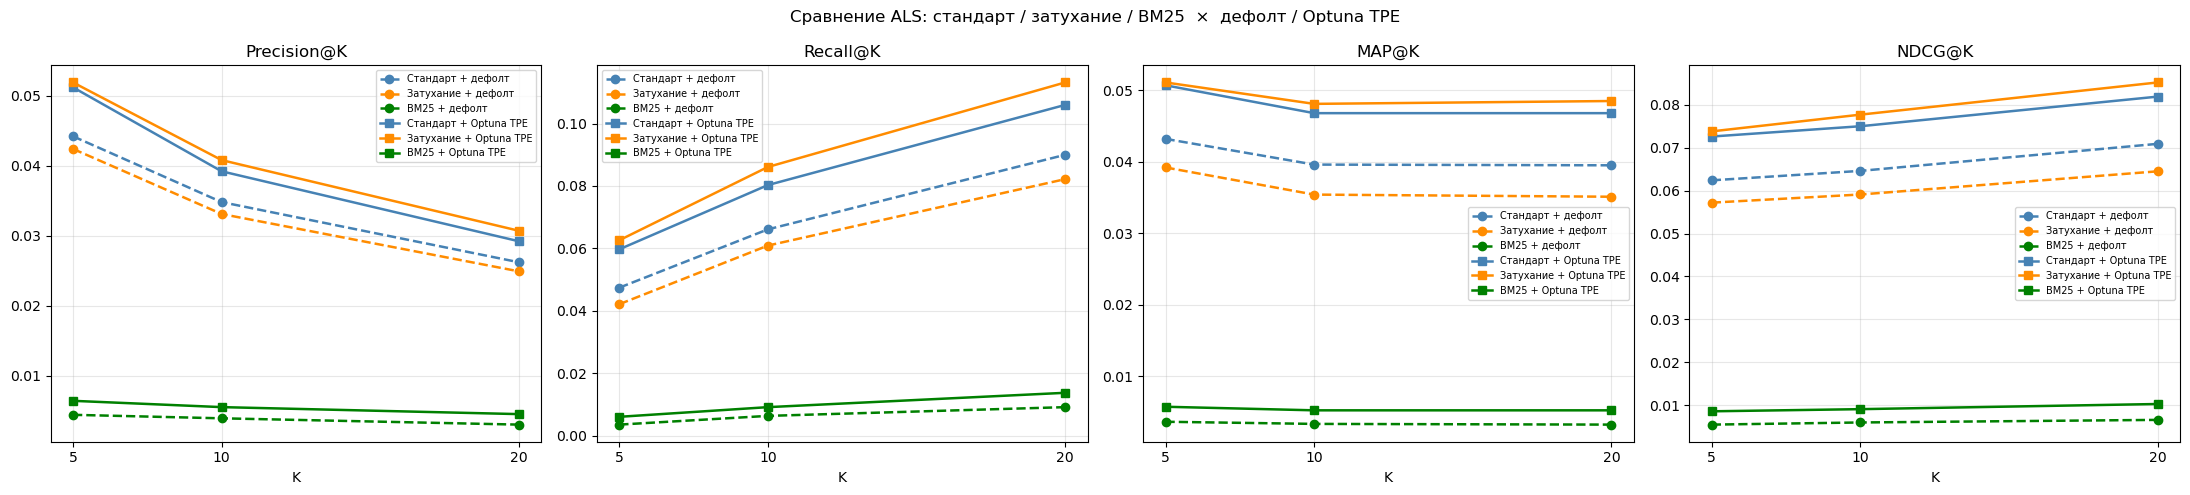

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
metrics = ['Precision', 'Recall', 'MAP', 'NDCG']
# дефолтные — пунктир, Optuna — сплошная; цвет = тип матрицы
style_map = {
    'Стандарт + дефолт':      ('steelblue',  '--', 'o'),
    'Затухание + дефолт':     ('darkorange', '--', 'o'),
    'BM25 + дефолт':          ('green',      '--', 'o'),
    'Стандарт + Optuna TPE':  ('steelblue',  '-',  's'),
    'Затухание + Optuna TPE': ('darkorange', '-',  's'),
    'BM25 + Optuna TPE':      ('green',      '-',  's'),
}
k_values = [5, 10, 20]

for ax, metric in zip(axes, metrics):
    for label, _ in all_variants:
        color, ls, marker = style_map[label]
        subset = comparison_df[comparison_df['Вариант'] == label]
        ax.plot(subset['K'], subset[metric],
                marker=marker, label=label, color=color,
                linestyle=ls, linewidth=1.8)
    ax.set_title(f'{metric}@K')
    ax.set_xlabel('K')
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle('Сравнение ALS: стандарт / затухание / BM25  ×  дефолт / Optuna TPE', fontsize=12)
plt.tight_layout()
plt.show()

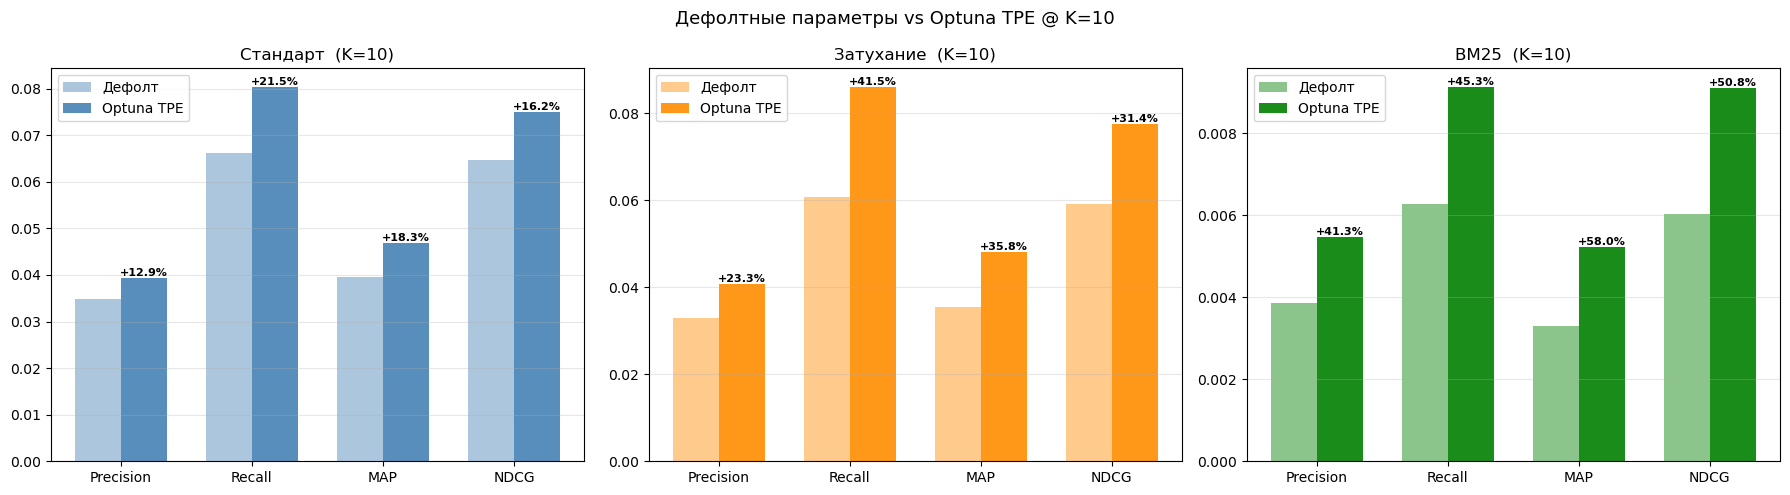

In [25]:
K_PLOT = 10
metric_names = ['Precision', 'Recall', 'MAP', 'NDCG']
metric_keys  = ['precision', 'recall', 'map', 'ndcg']

approaches = [
    ('Стандарт',  results_standard_baseline, results_standard_optuna, 'steelblue'),
    ('Затухание', results_decay_baseline,    results_decay_optuna,    'darkorange'),
    ('BM25',      results_bm25_baseline,     results_bm25_optuna,     'green'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(metric_names))
width = 0.35

for ax, (name, before, after, color) in zip(axes, approaches):
    vals_before = [before[K_PLOT][m] for m in metric_keys]
    vals_after  = [after[K_PLOT][m]  for m in metric_keys]

    ax.bar(x - width/2, vals_before, width, label='Дефолт',     color=color, alpha=0.45)
    ax.bar(x + width/2, vals_after,  width, label='Optuna TPE', color=color, alpha=0.9)

    for b_val, a_val, xi in zip(vals_before, vals_after, x):
        delta = (a_val - b_val) / b_val * 100 if b_val > 0 else 0
        ax.annotate(f'{delta:+.1f}%',
                    xy=(xi + width/2, a_val),
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(f'{name}  (K={K_PLOT})')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Дефолтные параметры vs Optuna TPE @ K={K_PLOT}', fontsize=13)
plt.tight_layout()
plt.show()

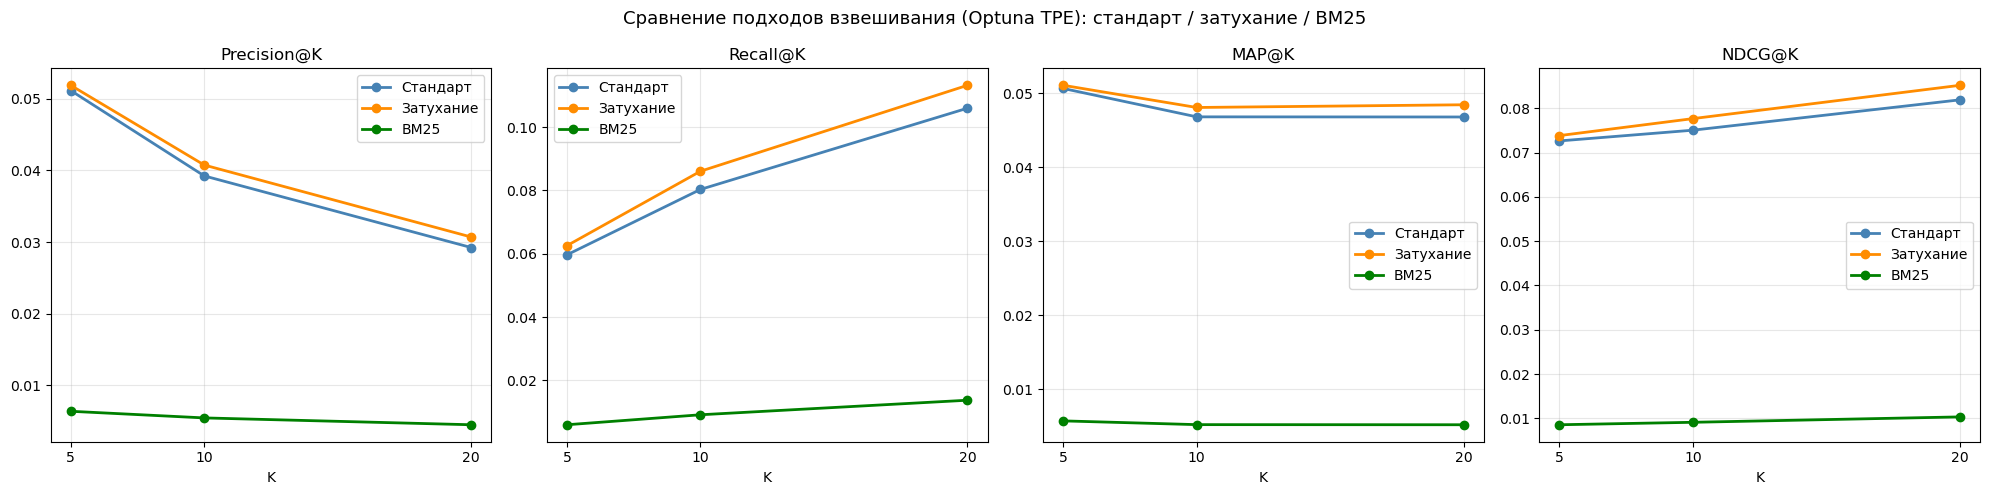

In [26]:
optuna_variants = [
    ('Стандарт',  results_standard_optuna, 'steelblue'),
    ('Затухание', results_decay_optuna,    'darkorange'),
    ('BM25',      results_bm25_optuna,     'green'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
k_values = [5, 10, 20]

for ax, (mname, mkey) in zip(axes, zip(metric_names, metric_keys)):
    for name, results, color in optuna_variants:
        vals = [results[k][mkey] for k in k_values]
        ax.plot(k_values, vals, marker='o', label=name, color=color, linewidth=2)
    ax.set_title(f'{mname}@K')
    ax.set_xlabel('K')
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Сравнение подходов взвешивания (Optuna TPE): стандарт / затухание / BM25', fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
lambdas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]

_base = train_data.groupby(['user_id', 'item_id']).agg(
    count=('count', 'sum'), mean_date=('Дата', 'mean')
).reset_index()
_user_ids = _base['user_id'].values
_item_ids = _base['item_id'].values
_counts   = _base['count'].values.astype(float)
_days     = (split_date - _base['mean_date']).dt.total_seconds().values / 86400

lambda_results = []
for lam in lambdas:
    weights = (_counts * np.exp(-lam * _days)).clip(1e-6)
    mat = csr_matrix((weights, (_user_ids, _item_ids)), shape=(n_users, n_items))

    m = AlternatingLeastSquares(
        factors=50, regularization=0.01, iterations=15,
        calculate_training_loss=False, random_state=42
    )
    m.fit(mat, show_progress=False)
    r = evaluate_model(m, mat, test_interactions, k_values=[5, 10, 20])

    row = {'lambda': lam}
    for k in [5, 10, 20]:
        for metric in ['precision', 'recall', 'map', 'ndcg']:
            row[f'{metric}@{k}'] = r[k][metric]
    lambda_results.append(row)
    print(f'lambda={lam:.3f}  MAP@5={r[5]["map"]:.4f}  MAP@10={r[10]["map"]:.4f}  MAP@20={r[20]["map"]:.4f}')

lambda_df = pd.DataFrame(lambda_results)
best_lam = lambdas[lambda_df['map@10'].argmax()]
print(f'\nОптимальный lambda по MAP@10: {best_lam}')
print(lambda_df[['lambda', 'map@5', 'map@10', 'map@20']].to_string(index=False))

lambda=0.001  MAP@5=0.0425  MAP@10=0.0389  MAP@20=0.0389
lambda=0.005  MAP@5=0.0405  MAP@10=0.0371  MAP@20=0.0370
lambda=0.010  MAP@5=0.0392  MAP@10=0.0354  MAP@20=0.0351
lambda=0.020  MAP@5=0.0367  MAP@10=0.0327  MAP@20=0.0323
lambda=0.050  MAP@5=0.0333  MAP@10=0.0291  MAP@20=0.0285
lambda=0.100  MAP@5=0.0296  MAP@10=0.0255  MAP@20=0.0250
lambda=0.200  MAP@5=0.0235  MAP@10=0.0200  MAP@20=0.0194

Оптимальный lambda по MAP@10: 0.001
 lambda    map@5   map@10   map@20
  0.001 0.042461 0.038933 0.038881
  0.005 0.040537 0.037131 0.036954
  0.010 0.039194 0.035434 0.035091
  0.020 0.036706 0.032666 0.032344
  0.050 0.033282 0.029123 0.028480
  0.100 0.029555 0.025547 0.024985
  0.200 0.023495 0.019970 0.019402


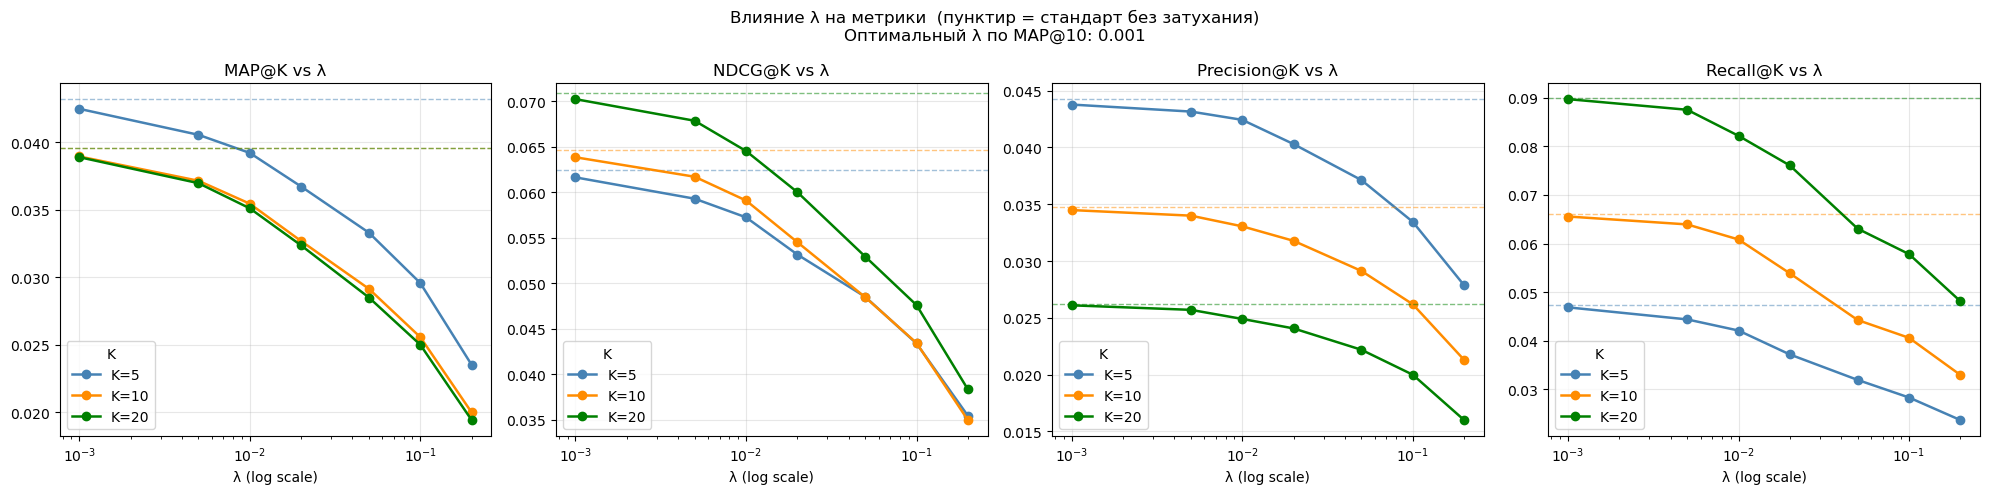

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
plot_pairs = [('MAP', 'map'), ('NDCG', 'ndcg'), ('Precision', 'precision'), ('Recall', 'recall')]

for ax, (mname, mkey) in zip(axes, plot_pairs):
    for k, color in [(5, 'steelblue'), (10, 'darkorange'), (20, 'green')]:
        ax.plot(lambda_df['lambda'], lambda_df[f'{mkey}@{k}'],
                marker='o', label=f'K={k}', color=color, linewidth=1.8)
        ax.axhline(results_standard_baseline[k][mkey],
                   color=color, linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('λ (log scale)')
    ax.set_title(f'{mname}@K vs λ')
    ax.legend(title='K')
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Влияние λ на метрики  (пунктир = стандарт без затухания)\n'
    f'Оптимальный λ по MAP@10: {best_lam}',
    fontsize=12
)
plt.tight_layout()
plt.show()

## Latency benchmark: ALS (CPU vs GPU)

Замеры per-user latency для финальной Optuna-модели на CPU и GPU (`implicit.gpu`). Метрики: mean / p50 / p95 (мс).

In [29]:
import sys
from pathlib import Path
_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    _utils = _cand / 'source' / 'utils'
    if _utils.exists():
        sys.path.insert(0, str(_utils))
        break
import importlib, timing as _t
importlib.reload(_t)
from timing import benchmark_user_latency, save_benchmark, detect_hardware

rng = np.random.RandomState(SEED)
eval_users_arr = test_warm['user_id'].unique()
sample_size = min(2000, len(eval_users_arr))
bench_users = rng.choice(eval_users_arr, size=sample_size, replace=False).tolist()
print(f'Benchmarking on {len(bench_users)} users (warmup=50, k=10)')


Benchmarking on 2000 users (warmup=50, k=10)


In [30]:
def als_cpu_recommend(uid):
    item_ids, _ = model_standard_optuna.recommend(
        uid, train_matrix_standard[uid], N=10, filter_already_liked_items=True
    )
    return item_ids

stats_cpu = benchmark_user_latency(
    als_cpu_recommend, bench_users, warmup=50, k=10, sync_cuda=False, label='ALS-CPU'
)
print(f"ALS-CPU: mean={stats_cpu['mean_ms']:.3f}ms  p50={stats_cpu['p50_ms']:.3f}ms  p95={stats_cpu['p95_ms']:.3f}ms  throughput={stats_cpu['throughput_ups']:.0f} u/s")

save_benchmark(
    stats_cpu, model_name='ALS-CPU', stage='single',
    hardware=detect_hardware(prefer='cpu'),
    dataset_meta={
        'n_users': N_USERS, 'n_items': N_ITEMS,
        'n_train_pairs': len(train_interactions),
        'min_interactions': MIN_INTERACTIONS,
        'split_quantile': SPLIT_QUANTILE,
    },
    extra={
        'library': 'implicit', 'factors': bp_std['factors'],
        'regularization': bp_std['regularization'],
        'iterations': bp_std['iterations'],
        'use_gpu': False, 'sync_cuda': False,
    },
    notebook='experiments/als_experiments.ipynb',
    n_items=N_ITEMS,
)

ALS-CPU: mean=0.116ms  p50=0.078ms  p95=0.180ms  throughput=8601 u/s


'ALS-CPU_single_20260509T152007'

In [31]:
import implicit
try:
    has_cuda = bool(implicit.gpu.HAS_CUDA)
except Exception:
    has_cuda = False
print(f'implicit.gpu.HAS_CUDA = {has_cuda}')

if has_cuda:
    from implicit.gpu.als import AlternatingLeastSquares as ALS_GPU
    factors_gpu = ((bp_std['factors'] + 31) // 32) * 32
    print(f'Training ALS-GPU (factors={factors_gpu}, iters={bp_std["iterations"]})')
    model_gpu = ALS_GPU(
        factors=factors_gpu,
        regularization=bp_std['regularization'],
        iterations=bp_std['iterations'],
        random_state=42,
    )
    model_gpu.fit(train_matrix_standard, show_progress=False)

    def als_gpu_recommend(uid):
        item_ids, _ = model_gpu.recommend(
            uid, train_matrix_standard[uid], N=10, filter_already_liked_items=True
        )
        return item_ids

    stats_gpu = benchmark_user_latency(
        als_gpu_recommend, bench_users, warmup=50, k=10, sync_cuda=False, label='ALS-GPU'
    )
    print(f"ALS-GPU: mean={stats_gpu['mean_ms']:.3f}ms  p50={stats_gpu['p50_ms']:.3f}ms  p95={stats_gpu['p95_ms']:.3f}ms  throughput={stats_gpu['throughput_ups']:.0f} u/s")

    save_benchmark(
        stats_gpu, model_name='ALS-GPU', stage='single',
        hardware=detect_hardware(prefer='gpu'),
        dataset_meta={
            'n_users': N_USERS, 'n_items': N_ITEMS,
            'n_train_pairs': len(train_interactions),
            'min_interactions': MIN_INTERACTIONS,
            'split_quantile': SPLIT_QUANTILE,
        },
        extra={
            'library': 'implicit', 'factors': factors_gpu,
            'regularization': bp_std['regularization'],
            'iterations': bp_std['iterations'],
            'use_gpu': True, 'implicit_HAS_CUDA': True,
            'sync_cuda': False,
        },
        notebook='experiments/als_experiments.ipynb',
        n_items=N_ITEMS,
    )
else:
    print('implicit GPU support not available; skipping ALS-GPU benchmark')

implicit.gpu.HAS_CUDA = False
implicit GPU support not available; skipping ALS-GPU benchmark
